# Corpus Quality Report — Stage 1
## Amazon Reviews: Books and Electronics

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

df = pd.read_parquet(r"C:\Users\tpasumarthi\thesis_syntactic_openings\01_processed\corpus.parquet")
print(f"Corpus shape: {df.shape}")
print(df['domain'].value_counts())

Corpus shape: (9999, 13)
domain
Electronics    5000
Books          4999
Name: count, dtype: int64


In [2]:
print("=== REVIEW LENGTH STATISTICS ===")
df['word_count'] = df['reviewText'].str.split().str.len()
print(df.groupby('domain')['word_count'].describe().round(2))

print("\n=== STAR RATING DISTRIBUTION ===")
print(df.groupby('domain')['overall'].value_counts().sort_index())

print("\n=== HELPFULNESS VOTE STATISTICS ===")
print(df.groupby('domain')['vote'].describe().round(2))

=== REVIEW LENGTH STATISTICS ===
              count    mean     std  min   25%    50%    75%     max
domain                                                              
Books        4999.0  215.72  226.18  5.0  76.0  148.0  275.5  3423.0
Electronics  5000.0  155.70  170.55  5.0  58.0  108.0  193.0  3588.0

=== STAR RATING DISTRIBUTION ===
domain       overall
Books        1.0         568
             2.0         513
             3.0         633
             4.0         900
             5.0        2385
Electronics  1.0         567
             2.0         292
             3.0         454
             4.0         953
             5.0        2734
Name: count, dtype: int64

=== HELPFULNESS VOTE STATISTICS ===
              count   mean    std  min  25%  50%   75%    max
domain                                                       
Books        4999.0  10.40  28.52  2.0  2.0  4.0   9.0  552.0
Electronics  5000.0  12.65  32.56  2.0  2.0  4.0  10.0  643.0


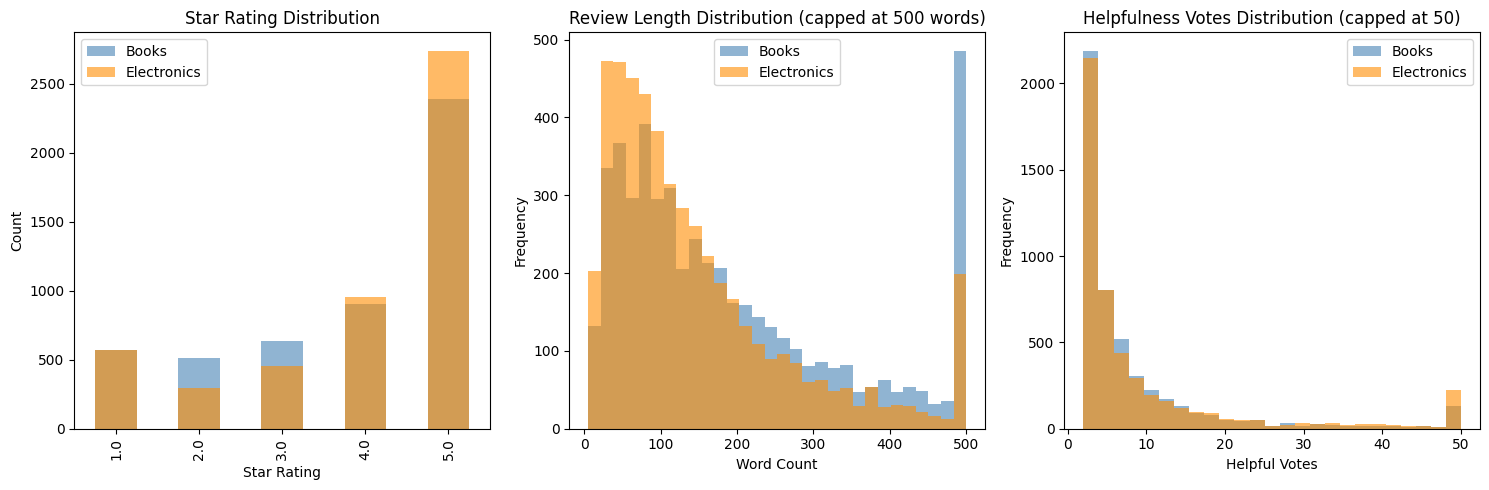

Figure saved.


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1 - Star rating distribution
for domain, color in [('Books', 'steelblue'), ('Electronics', 'darkorange')]:
    subset = df[df['domain'] == domain]
    subset['overall'].value_counts().sort_index().plot(
        kind='bar', ax=axes[0], alpha=0.6, color=color, label=domain)
axes[0].set_title('Star Rating Distribution')
axes[0].set_xlabel('Star Rating')
axes[0].set_ylabel('Count')
axes[0].legend()

# Plot 2 - Review length distribution
for domain, color in [('Books', 'steelblue'), ('Electronics', 'darkorange')]:
    subset = df[df['domain'] == domain]
    subset['word_count'].clip(upper=500).plot(
        kind='hist', ax=axes[1], alpha=0.6, bins=30, color=color, label=domain)
axes[1].set_title('Review Length Distribution (capped at 500 words)')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].legend()

# Plot 3 - Helpfulness vote distribution
for domain, color in [('Books', 'steelblue'), ('Electronics', 'darkorange')]:
    subset = df[df['domain'] == domain]
    subset['vote'].clip(upper=50).plot(
        kind='hist', ax=axes[2], alpha=0.6, bins=25, color=color, label=domain)
axes[2].set_title('Helpfulness Votes Distribution (capped at 50)')
axes[2].set_xlabel('Helpful Votes')
axes[2].set_ylabel('Frequency')
axes[2].legend()

plt.tight_layout()
os.makedirs(r"C:\Users\tpasumarthi\thesis_syntactic_openings\01_processed\figures", exist_ok=True)
plt.savefig(r"C:\Users\tpasumarthi\thesis_syntactic_openings\01_processed\figures\corpus_distributions.png", dpi=150)
plt.show()
print("Figure saved.")

In [4]:
summary = df.groupby('domain').agg(
    n_reviews=('reviewText', 'count'),
    mean_words=('word_count', 'mean'),
    median_words=('word_count', 'median'),
    mean_rating=('overall', 'mean'),
    mean_votes=('vote', 'mean')
).round(2)

print(summary)
summary.to_csv(r"C:\Users\tpasumarthi\thesis_syntactic_openings\01_processed\corpus_summary.csv")
print("Summary saved.")

             n_reviews  mean_words  median_words  mean_rating  mean_votes
domain                                                                   
Books             4999      215.72         148.0          3.8       10.40
Electronics       5000      155.70         108.0          4.0       12.65
Summary saved.
